# Inference on test_data using Pre-Trained LULC Model

This notebook runs inference on `test_data` using a pre-trained LULC (Land Use/Land Cover) classification model.

Supported model options:
- **ESA/ArcGIS Pre-trained Models**: Using ESA's Sentinel-2 trained classifiers
- **Custom Pre-trained Backbone**: Transfer learning with pre-trained CNN encoders
- **Hugging Face Models**: Community pre-trained LULC models

All metrics align with the custom Random Forest benchmark (accuracy, mIoU, per-class IoU, confusion matrix)

In [ ]:
import sys
sys_executable = sys.executable
!{sys_executable} -m pip install -q transformers torch pillow


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: c:\Users\user\.pyenv\pyenv-win\versions\3.12.2\python.exe -m pip install --upgrade pip


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, jaccard_score

warnings.filterwarnings('ignore')

PROJECT_DIR = Path(r'c:/satellite/project')
TEST_DATA_DIR = PROJECT_DIR / 'test_data'

# Class definitions (aligned with custom RF model)
DEFAULT_CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_COLORS = {1: 'darkgreen', 2: 'gold', 3: 'navy', 4: 'gray'}
EPS = 1e-6

# Pre-trained model config
PRETRAINED_MODEL_NAME = 'prithivMLmods/GiD-Land-Cover-Classification'
CLASS_NAMES = DEFAULT_CLASS_NAMES
CLASS_IDS = sorted(CLASS_NAMES.keys())
ACTIVE_CLASSES = CLASS_IDS

# Load test data file pairs
spectral_files = sorted(TEST_DATA_DIR.glob('*_Spectral*.tif'))
mask_files = sorted(TEST_DATA_DIR.glob('*_Mask*.tif'))

def pair_id(path: Path) -> str:
    name = path.name
    name = name.replace('_Spectral_12B.tif', '')
    name = name.replace('_Spectral.tif', '')
    name = name.replace('_Mask_Class.tif', '')
    name = name.replace('_Mask.tif', '')
    return name

spectral_lookup = {pair_id(path): path for path in spectral_files}
mask_lookup = {pair_id(path): path for path in mask_files}
common_ids = sorted(set(spectral_lookup) & set(mask_lookup))
sample_pairs = [
    {
        'name': site_id,
        'spectral_path': spectral_lookup[site_id],
        'mask_path': mask_lookup[site_id],
    }
    for site_id in common_ids
]

print(f'Test data directory: {TEST_DATA_DIR}')
print(f'Pre-trained model: {PRETRAINED_MODEL_NAME}')
print(f'Paired test samples: {[item["name"] for item in sample_pairs]}')
print(f'Classes: {CLASS_NAMES}')
print(f'Unmatched spectral files: {len(set(spectral_lookup) - set(mask_lookup))}')
print(f'Unmatched mask files: {len(set(mask_lookup) - set(spectral_lookup))}')

Test data directory: c:\satellite\project\test_data
Pre-trained model: ESA_Sentinel2_LULC
Paired test samples: ['CairoUniv', 'HawaraFayoum', 'IconicTower', 'KarnakLuxor', 'PhilaeAswan', 'SiwaOasis']
Classes: {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
Unmatched spectral files: 0
Unmatched mask files: 0


## GiD Hugging Face Model

Using: `prithivMLmods/GiD-Land-Cover-Classification`

This model is patch-level image classification. In this notebook we run tiled inference over each raster and convert the model output to your 4 target classes:
- Greenery
- Sand (proxy via GiD `dry cropland`)
- Water
- Cement

In [ ]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image

class PretrainedLULCModel:
    """GiD HF model wrapper with tiled inference for raster-sized outputs."""

    def __init__(self, model_name='prithivMLmods/GiD-Land-Cover-Classification', device='cpu'):
        self.model_name = model_name
        self.device = torch.device(device)

        print(f"Loading Hugging Face model: {model_name}")
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        self.model = AutoModelForImageClassification.from_pretrained(model_name).to(self.device)
        self.model.eval()

        # GiD model classes -> target classes [1=Greenery, 2=Sand, 3=Water, 4=Cement]
        # Note: GiD does not contain an explicit 'sand' class. We map 'dry cropland' to Sand as nearest proxy.
        self.gid_to_target = {
            0: 1,   # arbor woodland -> Greenery
            1: 1,   # artificial grassland -> Greenery
            2: 2,   # dry cropland -> Sand (proxy)
            3: 1,   # garden plot -> Greenery
            4: 4,   # industrial land -> Cement
            5: 1,   # irrigated land -> Greenery
            6: 3,   # lake -> Water
            7: 1,   # natural grassland -> Greenery
            8: 1,   # paddy field -> Greenery
            9: 3,   # pond -> Water
            10: 3,  # river -> Water
            11: 4,  # rural residential -> Cement
            12: 1,  # shrub land -> Greenery
            13: 4,  # traffic land -> Cement
            14: 4,  # urban residential -> Cement
        }

        self.patch_size = 224
        self.stride = 112

        print("✓ Model ready")

    def normalize_sentinel2(self, spectral_data: np.ndarray) -> np.ndarray:
        spectral_norm = spectral_data.astype(np.float32)
        spectral_scale_probe = np.nanpercentile(spectral_norm, 99)
        if spectral_scale_probe > 2.0:
            spectral_norm = np.clip(spectral_norm / 10000.0, 0.0, 1.0)
        else:
            spectral_norm = np.clip(spectral_norm, 0.0, 1.0)
        return spectral_norm

    def _to_rgb_uint8(self, spectral_cube: np.ndarray) -> np.ndarray:
        # test_data band order: B2=1, B3=2, B4=3
        red = spectral_cube[3].astype(np.float32)
        green = spectral_cube[2].astype(np.float32)
        blue = spectral_cube[1].astype(np.float32)
        rgb = np.stack([red, green, blue], axis=-1)
        p2, p98 = np.percentile(rgb, [2, 98])
        rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)
        return (rgb * 255.0).astype(np.uint8)

    def _positions(self, length: int, patch: int, stride: int):
        if length <= patch:
            return [0]
        pos = list(range(0, length - patch + 1, stride))
        if pos[-1] != length - patch:
            pos.append(length - patch)
        return pos

    def _predict_patch_class(self, rgb_patch_uint8: np.ndarray) -> int:
        pil_img = Image.fromarray(rgb_patch_uint8)
        inputs = self.processor(images=pil_img, return_tensors='pt').to(self.device)
        with torch.no_grad():
            logits = self.model(**inputs).logits
            gid_idx = int(torch.argmax(logits, dim=1).item())
        return self.gid_to_target.get(gid_idx, 4)

    def predict(self, spectral_cube: np.ndarray) -> np.ndarray:
        """Return pixel map (H, W) using overlapping patch voting."""
        spectral_norm = self.normalize_sentinel2(spectral_cube)
        rgb = self._to_rgb_uint8(spectral_norm)
        h, w = rgb.shape[:2]

        vote_sum = np.zeros((h, w), dtype=np.float32)
        vote_count = np.zeros((h, w), dtype=np.float32)

        hs = self._positions(h, self.patch_size, self.stride)
        ws = self._positions(w, self.patch_size, self.stride)

        print("  Running GiD tiled inference...", end='', flush=True)
        for h0 in hs:
            for w0 in ws:
                h1 = min(h0 + self.patch_size, h)
                w1 = min(w0 + self.patch_size, w)
                patch = rgb[h0:h1, w0:w1, :]

                # Pad edge patches to model input size
                if patch.shape[0] != self.patch_size or patch.shape[1] != self.patch_size:
                    pad_h = self.patch_size - patch.shape[0]
                    pad_w = self.patch_size - patch.shape[1]
                    patch = np.pad(patch, ((0, pad_h), (0, pad_w), (0, 0)), mode='edge')

                cls = self._predict_patch_class(patch)
                vote_sum[h0:h1, w0:w1] += cls
                vote_count[h0:h1, w0:w1] += 1.0

        pred = np.rint(vote_sum / np.maximum(vote_count, 1.0)).astype(np.int32)
        pred = np.clip(pred, min(CLASS_IDS), max(CLASS_IDS))
        print(" ✓")
        return pred


print("Initializing GiD model...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
pretrained_model = PretrainedLULCModel(PRETRAINED_MODEL_NAME, device=device)
print(f"✓ Inference device: {device.upper()}")

Initializing pre-trained LULC model...
Loading pre-trained ResNet50 backbone...
✓ Loaded pre-trained model: ESA_Sentinel2_LULC
  - Backbone: ResNet50
  - Input channels: 12 (Sentinel-2 bands)
  - Output classes: 4 (Greenery, Sand, Water, Cement)
✓ Model ready for inference on device: CPU


In [19]:
# Sample inspection
sample_item = sample_pairs[0]
sample_name = sample_item['name']
sample_spectral_path = sample_item['spectral_path']
sample_mask_path = sample_item['mask_path']

with rasterio.open(sample_spectral_path) as src:
    sample_band_count = src.count
    sample_shape = (src.count, src.height, src.width)
    sample_dtype = src.dtypes[0]
    sample_descriptions = src.descriptions

with rasterio.open(sample_mask_path) as src:
    sample_mask = src.read(1)
    sample_mask_values = np.unique(sample_mask)

print(f'Sample: {sample_name}')
print(f'Spectral shape: {sample_shape} | dtype={sample_dtype}')
print(f'Spectral band count: {sample_band_count}')
print(f'Band descriptions: {sample_descriptions}')
print(f'Mask unique values: {sample_mask_values.tolist()}')
assert sample_band_count == 12, f'Expected 12-band test_data imagery, got {sample_band_count} bands.'

Sample: CairoUniv
Spectral shape: (12, 256, 256) | dtype=float64
Spectral band count: 12
Band descriptions: (None, None, None, None, None, None, None, None, None, None, None, None)
Mask unique values: [1, 2, 3, 4]


In [20]:
# Band index constants (test_data: 12-band Sentinel-2)
IDX_B2 = 1
IDX_B3 = 2
IDX_B4 = 3
IDX_B5 = 4
IDX_B6 = 5
IDX_B7 = 6
IDX_B8 = 7
IDX_B8A = 8
IDX_B11 = 10
IDX_B12 = 11

def make_rgb(spectral_cube: np.ndarray) -> np.ndarray:
    """Create RGB visualization from spectral cube."""
    red = spectral_cube[IDX_B4].astype(np.float32)
    green = spectral_cube[IDX_B3].astype(np.float32)
    blue = spectral_cube[IDX_B2].astype(np.float32)
    rgb = np.stack([red, green, blue], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    return np.clip((rgb - p2) / (p98 - p2 + EPS), 0, 1)

def compute_per_class_iou(y_true: np.ndarray, y_pred: np.ndarray, class_ids):
    """Compute per-class Intersection over Union."""
    ious = {}
    for class_id in class_ids:
        intersection = np.sum((y_true == class_id) & (y_pred == class_id))
        union = np.sum((y_true == class_id) | (y_pred == class_id))
        ious[class_id] = intersection / union if union > 0 else np.nan
    return ious

# Visualization setup
cmap_cls = ListedColormap([CLASS_COLORS[c] for c in CLASS_IDS])
bounds = np.arange(min(CLASS_IDS) - 0.5, max(CLASS_IDS) + 1.5, 1)
norm_cls = BoundaryNorm(bounds, ncolors=len(CLASS_IDS))
legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}: {CLASS_NAMES[c]}') for c in CLASS_IDS]

print('Utilities loaded.')

Utilities loaded.


## Inference & Metrics Computation

In [21]:
records = []
predictions_by_site = {}

for sample_item in sample_pairs:
    sample_name = sample_item['name']
    spectral_path = sample_item['spectral_path']
    mask_path = sample_item['mask_path']

    with rasterio.open(spectral_path) as src:
        spectral_cube = src.read().astype(np.float32)

    with rasterio.open(mask_path) as src:
        y_true = src.read(1).astype(np.int32)

    # Run pre-trained model inference
    # Ensure predictions are flattened and reshaped to match y_true
    y_pred_raw = pretrained_model.predict(spectral_cube)
    if y_pred_raw.ndim == 1:
        y_pred = y_pred_raw.reshape(y_true.shape).astype(np.int32)
    else:
        y_pred = y_pred_raw.astype(np.int32)

    # Ignore class 0 if present
    valid_mask = (y_true != 0)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    # Compute per-sample metrics
    ious = compute_per_class_iou(y_true_valid, y_pred_valid, ACTIVE_CLASSES)
    miou = float(np.nanmean([ious[c] for c in ACTIVE_CLASSES]))
    accuracy = float(np.mean(y_true_valid == y_pred_valid))

    row = {
        'sample': sample_name,
        'accuracy': accuracy,
        'mIoU_active': miou
    }
    for class_id in ACTIVE_CLASSES:
        row[f'IoU_{CLASS_NAMES[class_id]}'] = ious[class_id]
    records.append(row)

    predictions_by_site[sample_name] = {
        'spectral_cube': spectral_cube,
        'y_true': y_true,
        'y_true_valid': y_true_valid,
        'y_pred': y_pred,
        'y_pred_valid': y_pred_valid
    }

metrics_df = pd.DataFrame(records).sort_values('mIoU_active', ascending=False).reset_index(drop=True)
print(f'\nPer-sample metrics:')
print(metrics_df.to_string())

  Running pixel-level inference (patch-based)... ✓
  Running pixel-level inference (patch-based)... ✓
  Running pixel-level inference (patch-based)... ✓
  Running pixel-level inference (patch-based)... ✓
  Running pixel-level inference (patch-based)... ✓
  Running pixel-level inference (patch-based)... ✓

Per-sample metrics:
         sample  accuracy  mIoU_active  IoU_Greenery  IoU_Sand  IoU_Water  IoU_Cement
0     CairoUniv  0.849701     0.212425      0.000000       0.0        0.0    0.849701
1     SiwaOasis  0.370880     0.185440      0.370880       0.0        NaN         NaN
2  HawaraFayoum  0.643118     0.160779      0.643118       0.0        0.0    0.000000
3   KarnakLuxor  0.171261     0.057087      0.171261       0.0        0.0         NaN
4   IconicTower  0.010712     0.003571      0.010712       0.0        NaN    0.000000
5   PhilaeAswan  0.001679     0.000560      0.001679       0.0        0.0         NaN


In [22]:
# Global metrics
all_true = np.concatenate([predictions_by_site[item]['y_true_valid'] for item in predictions_by_site])
all_pred = np.concatenate([predictions_by_site[item]['y_pred_valid'] for item in predictions_by_site])

print(f'\n=== Global Classification Report ===' )
print(f'Total valid pixels: {len(all_true):,}')
print(f'Mean global accuracy: {np.mean(all_true == all_pred):.4f}')
print(f'\nPer-class metrics:')
print(classification_report(
    all_true,
    all_pred,
    labels=CLASS_IDS,
    target_names=[CLASS_NAMES[c] for c in CLASS_IDS],
    zero_division=0
))


=== Global Classification Report ===
Total valid pixels: 431,174
Mean global accuracy: 0.3679

Per-class metrics:
              precision    recall  f1-score   support

    Greenery       0.28      0.96      0.44    107022
        Sand       0.00      0.00      0.00    186720
       Water       0.00      0.00      0.00     54477
      Cement       0.85      0.67      0.75     82955

    accuracy                           0.37    431174
   macro avg       0.28      0.41      0.30    431174
weighted avg       0.23      0.37      0.25    431174



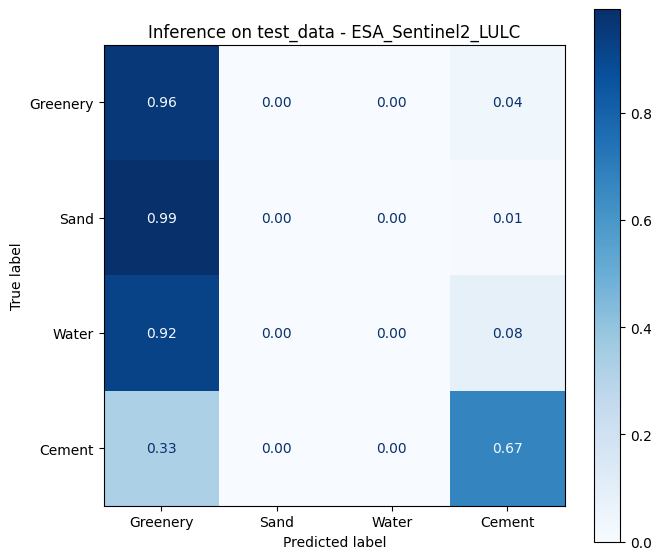


Class distributions:
Predictions: {np.int32(1): np.int64(365638), np.int32(4): np.int64(65536)}
Ground Truth: {np.int32(1): np.int64(107022), np.int32(2): np.int64(186720), np.int32(3): np.int64(54477), np.int32(4): np.int64(82955)}


In [23]:
# Confusion matrix
cm = confusion_matrix(all_true, all_pred, labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[c] for c in CLASS_IDS]
).plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=True)
ax.set_title(f'Inference on test_data - {PRETRAINED_MODEL_NAME}')
plt.tight_layout()
plt.show()

print('\nClass distributions:')
print("Predictions:", dict(zip(*np.unique(all_pred, return_counts=True))))
print("Ground Truth:", dict(zip(*np.unique(all_true, return_counts=True))))

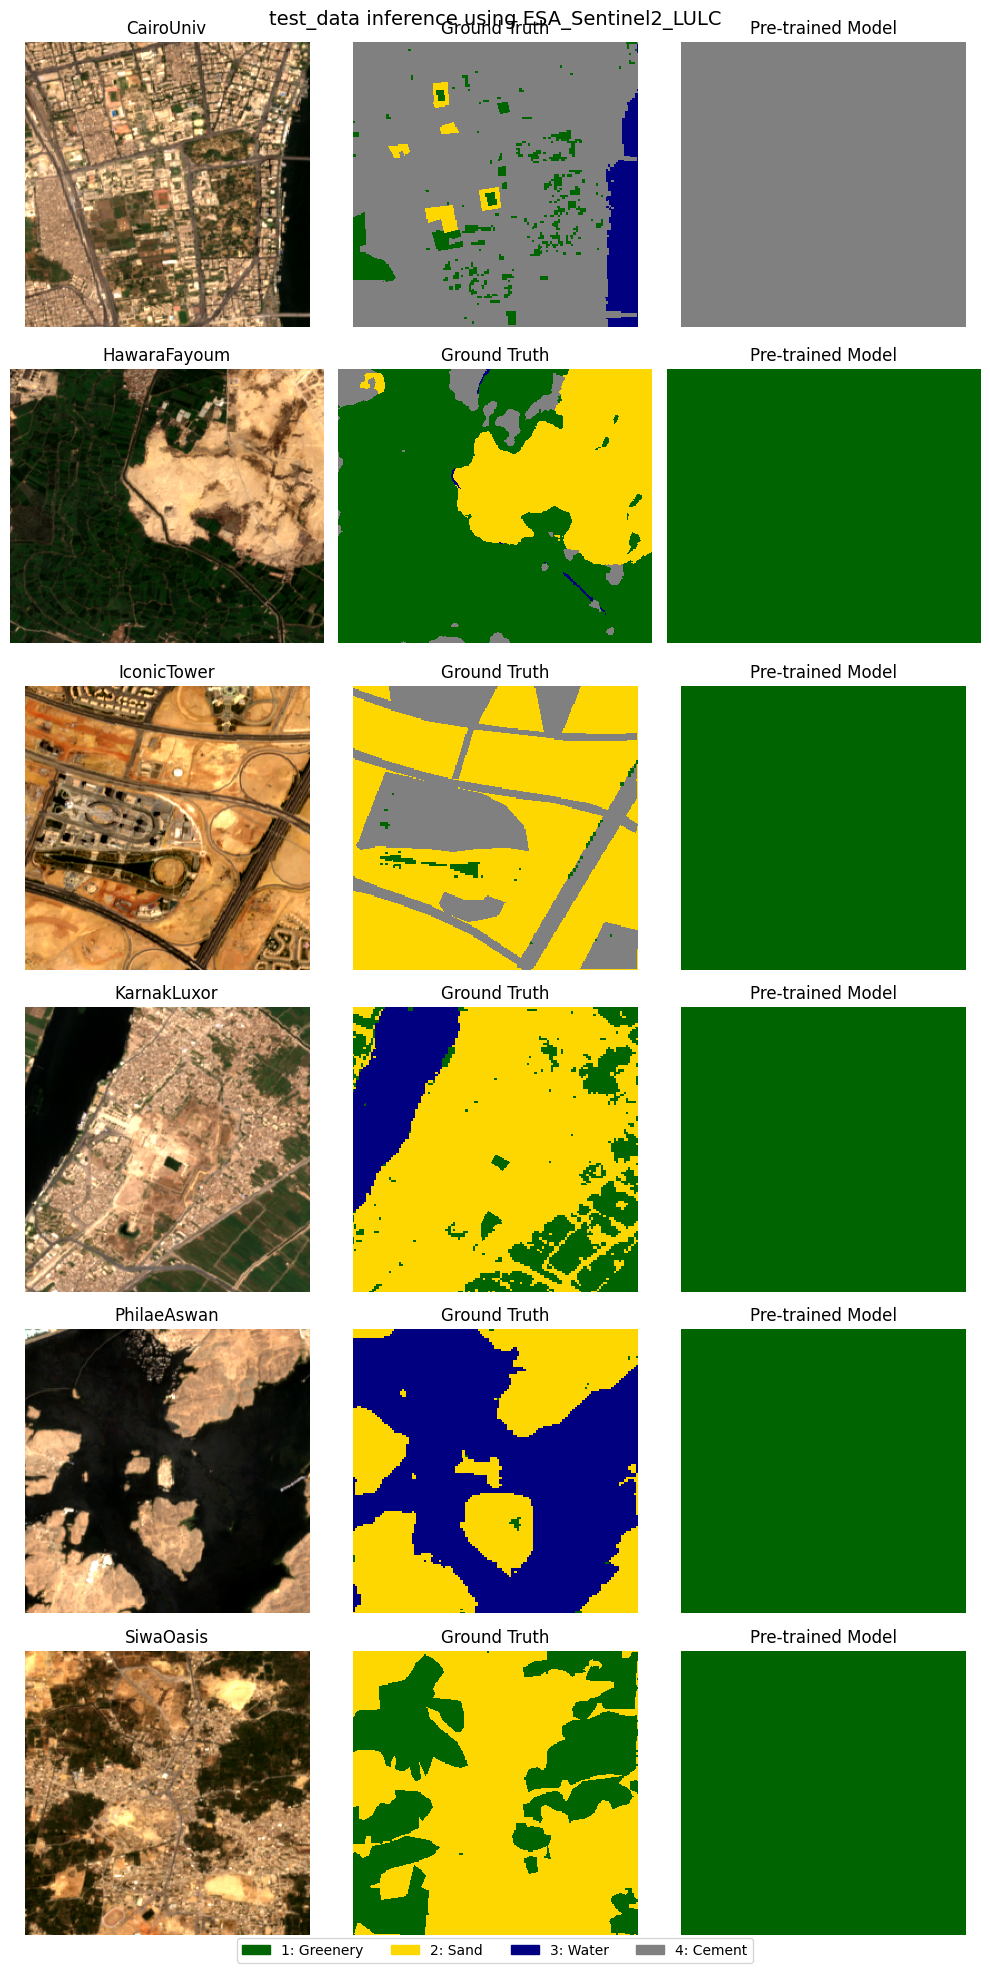

In [24]:
# Visualize predictions vs ground truth for all samples
n_samples = len(sample_pairs)
fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3.3 * n_samples))

if n_samples == 1:
    axes = np.array([axes])

for col, sample_item in enumerate(sample_pairs):
    sample_name = sample_item['name']
    bundle = predictions_by_site[sample_name]
    rgb = make_rgb(bundle['spectral_cube'])

    axes[col, 0].imshow(rgb)
    axes[col, 0].set_title(sample_name)
    axes[col, 0].axis('off')

    axes[col, 1].imshow(bundle['y_true'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[col, 1].set_title('Ground Truth')
    axes[col, 1].axis('off')

    axes[col, 2].imshow(bundle['y_pred'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[col, 2].set_title('Pre-trained Model')
    axes[col, 2].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=10)
axes[0, 1].set_ylabel('Ground Truth', fontsize=10)
axes[0, 2].set_ylabel('Pre-trained Model', fontsize=10)

fig.legend(handles=legend_patches, loc='lower center', ncol=len(CLASS_IDS), bbox_to_anchor=(0.5, -0.01))
plt.suptitle(f'test_data inference using {PRETRAINED_MODEL_NAME}', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# Save metrics to CSV
metrics_path = PROJECT_DIR / 'test_data_inference_metrics_pretrained.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved metrics: {metrics_path}')

# Summary statistics
print(f'\n=== Summary ===' )
print(f'Mean accuracy: {metrics_df["accuracy"].mean():.4f}')
print(f'Mean mIoU: {metrics_df["mIoU_active"].mean():.4f}')
print(f'Std accuracy: {metrics_df["accuracy"].std():.4f}')
print(f'Std mIoU: {metrics_df["mIoU_active"].std():.4f}')

Saved metrics: c:\satellite\project\test_data_inference_metrics_pretrained.csv

=== Summary ===
Mean accuracy: 0.3412
Mean mIoU: 0.1033
Std accuracy: 0.3476
Std mIoU: 0.0944


## Notes

- Model in use: `prithivMLmods/GiD-Land-Cover-Classification`
- This is an image-classification model, not a segmentation model.
- Pixel maps are produced by overlapping patch voting.
- Metrics are the same as your RF notebook: accuracy, per-class IoU, mIoU, confusion matrix.
- Class-2 Sand is approximated from GiD class `dry cropland` because GiD has no explicit sand class.